# Bidirectional incremental error-reparameterised Predictive Coding (biePC)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/thebuckleylab/jpc/blob/main/examples/biepc.ipynb)

This notebook demonstrates **biePC**, which combines the bidirectional PC architecture ([Oliviers et al., 2025](https://arxiv.org/abs/2505.23415)), the error reparameterisation of [ePC](https://arxiv.org/abs/2505.20137) ([Goemaere et al., 2025](https://arxiv.org/abs/2505.20137)), and the incremental interleaving of error and parameter updates from [iPC](https://arxiv.org/abs/2212.00720) ([Salvatori et al., 2024](https://arxiv.org/abs/2212.00720)). It is to [`bepc.ipynb`](./bepc.ipynb) what [`iepc.ipynb`](./iepc.ipynb) is to [`epc.ipynb`](./epc.ipynb): instead of waiting for the error dynamics to relax before a single joint weight update of the top-down and bottom-up networks, biePC interleaves error and parameter updates at every inference step.

As in bePC, we use a top-down (generative) network and a bottom-up (discriminative) network, the inference variables are the forward prediction errors $\{\epsilon_\ell\}$, activities are recovered on-the-fly through an error-perturbed forward pass $\tilde{z}_\ell = f_\ell(\tilde{z}_{\ell-1}) + \epsilon_\ell$, and the bPC backward energy $\|\tilde{z}_\ell - g_{\ell+1}(\tilde{z}_{\ell+1})\|^2$ is evaluated on those perturbed activities.

The total energy is
$$
\mathcal{F} = \alpha_f \Big[ \sum_{\ell=1}^{L-1} \tfrac{1}{2}\|\epsilon_\ell\|^2 + \tfrac{1}{2}\|\mathbf{y} - \tilde{f}(\mathbf{x}, \epsilon)\|^2 \Big] + \alpha_b \sum_{\ell=0}^{L-1} \tfrac{1}{2}\|\tilde{\mathbf{z}}_\ell - g_{\ell+1}(\tilde{\mathbf{z}}_{\ell+1})\|^2.
$$

We train on MNIST in the same setup as [`bepc.ipynb`](./bepc.ipynb) and [`bidirectional_pc.ipynb`](./bidirectional_pc.ipynb): a joint generator/classifier where $x$ is the one-hot label and $y$ is the image.

In [ ]:
%%capture
!pip install torch==2.3.1
!pip install torchvision==0.18.1
!pip install matplotlib==3.0.0

In [1]:
import jpc

import jax
import jax.numpy as jnp
import equinox as eqx
import optax

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt

import warnings
warnings.simplefilter('ignore')  # ignore warnings

## Hyperparameters

In [2]:
SEED = 0

INPUT_DIM = 10
WIDTH = 256
DEPTH = 2
OUTPUT_DIM = 784
ACT_FN = "relu"

ERROR_LR = 5e-1
PARAM_LR = 1e-3
BATCH_SIZE = 64
TEST_EVERY = 50
N_TRAIN_ITERS = 300

## Dataset

Some utils to fetch MNIST.

In [3]:
def get_mnist_loaders(batch_size):
    train_data = MNIST(train=True, normalise=True)
    test_data = MNIST(train=False, normalise=True)
    train_loader = DataLoader(
        dataset=train_data,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True
    )
    test_loader = DataLoader(
        dataset=test_data,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True
    )
    return train_loader, test_loader


class MNIST(datasets.MNIST):
    def __init__(self, train, normalise=True, save_dir="data"):
        if normalise:
            transform = transforms.Compose(
                [
                    transforms.ToTensor(),
                    transforms.Normalize(
                        mean=(0.1307), std=(0.3081)
                    )
                ]
            )
        else:
            transform = transforms.Compose([transforms.ToTensor()])
        super().__init__(save_dir, download=True, train=train, transform=transform)

    def __getitem__(self, index):
        img, label = super().__getitem__(index)
        img = torch.flatten(img)
        label = one_hot(label)
        return img, label


def one_hot(labels, n_classes=10):
    arr = torch.eye(n_classes)
    return arr[labels]


def plot_mnist_imgs(imgs, labels, n_imgs=10):
    plt.figure(figsize=(20, 2))
    for i in range(n_imgs):
        plt.subplot(1, n_imgs, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(imgs[i].reshape(28, 28), cmap=plt.cm.binary_r)
        plt.xlabel(jnp.argmax(labels, axis=1)[i])
    plt.show()

## Train and test

The key difference from bePC is that `jpc.update_bepc_params` is called inside the inference loop, at every error-update step, rather than once after the error dynamics have relaxed. Errors are reset to zero at the start of each batch with `jpc.init_epc_errors`.

In [4]:
def evaluate(generator, amortiser, test_loader):
    amort_accs = 0.
    for _, (img_batch, label_batch) in enumerate(test_loader):
        img_batch, label_batch = img_batch.numpy(), label_batch.numpy()

        preds = jpc.init_activities_with_ffwd(
            model=amortiser[::-1],
            input=img_batch
        )[-1]
        amort_accs += jpc.compute_accuracy(label_batch, preds)

    img_preds = jpc.init_activities_with_ffwd(
        model=generator,
        input=label_batch
    )[-1]

    return (
        amort_accs / len(test_loader),
        label_batch,
        img_preds
    )


def train(
      seed,
      input_dim,
      width,
      depth,
      output_dim,
      act_fn,
      batch_size,
      error_lr,
      param_lr,
      test_every,
      n_train_iters,
      forward_energy_weight=1.0
):
    key = jax.random.PRNGKey(seed)
    gen_key, amort_key = jax.random.split(key, 2)

    # models (NOTE: input and output are inverted for the amortiser)
    generator = jpc.make_mlp(
        gen_key,
        input_dim=input_dim,
        width=width,
        depth=depth,
        output_dim=output_dim,
        act_fn=act_fn
    )
    amortiser = jpc.make_mlp(
        amort_key,
        input_dim=output_dim,
        width=width,
        depth=depth,
        output_dim=input_dim,
        act_fn=act_fn
    )[::-1]

    # optimisers
    error_optim = optax.sgd(error_lr)
    gen_optim = optax.adam(param_lr)
    amort_optim = optax.adam(param_lr)
    gen_opt_state = gen_optim.init(eqx.filter(generator, eqx.is_array))
    amort_opt_state = amort_optim.init(eqx.filter(amortiser, eqx.is_array))

    layer_sizes = [input_dim] + [width] * (depth - 1) + [output_dim]

    # data
    train_loader, test_loader = get_mnist_loaders(batch_size)

    for iter, (img_batch, label_batch) in enumerate(train_loader):
        img_batch, label_batch = img_batch.numpy(), label_batch.numpy()

        # feedforward losses (for logging only)
        amort_preds = jpc.init_activities_with_ffwd(
            model=amortiser[::-1],
            input=img_batch
        )[-1]
        amort_loss = jpc.mse_loss(amort_preds, label_batch)

        gen_preds = jpc.init_activities_with_ffwd(
            model=generator,
            input=label_batch
        )[-1]
        gen_loss = jpc.mse_loss(gen_preds, img_batch)

        # biePC: initialise errors to zero and interleave inference with learning
        errors = jpc.init_epc_errors(
            layer_sizes=layer_sizes,
            batch_size=batch_size
        )
        error_opt_state = error_optim.init(errors)

        for _ in range(depth - 1):
            error_update_result = jpc.update_bepc_errors(
                top_down_model=generator,
                bottom_up_model=amortiser,
                errors=errors,
                optim=error_optim,
                opt_state=error_opt_state,
                output=img_batch,
                input=label_batch,
                forward_energy_weight=forward_energy_weight
            )
            errors = error_update_result["errors"]
            error_opt_state = error_update_result["opt_state"]

            param_update_result = jpc.update_bepc_params(
                top_down_model=generator,
                bottom_up_model=amortiser,
                errors=errors,
                top_down_optim=gen_optim,
                bottom_up_optim=amort_optim,
                top_down_opt_state=gen_opt_state,
                bottom_up_opt_state=amort_opt_state,
                output=img_batch,
                input=label_batch,
                forward_energy_weight=forward_energy_weight
            )
            generator, amortiser = param_update_result["models"]
            gen_opt_state, amort_opt_state = param_update_result["opt_states"]

        if ((iter+1) % test_every) == 0:
            amort_acc, label_batch, img_preds = evaluate(
                generator,
                amortiser,
                test_loader
            )
            print(
                f"Iter {iter+1}, gen loss={gen_loss:4f}, "
                f"amort loss={amort_loss:4f}, "
                f"avg amort test accuracy={amort_acc:4f}"
            )

            if (iter+1) >= n_train_iters:
                break

    plot_mnist_imgs(img_preds, label_batch)

## Run

Iter 50, gen loss=264.652832, amort loss=0.267955, avg amort test accuracy=79.016426
Iter 100, gen loss=217.735825, amort loss=0.239421, avg amort test accuracy=82.031250
Iter 150, gen loss=226.008102, amort loss=0.203767, avg amort test accuracy=83.914261
Iter 200, gen loss=232.282410, amort loss=0.200225, avg amort test accuracy=83.042870
Iter 250, gen loss=215.741867, amort loss=0.193226, avg amort test accuracy=82.782455
Iter 300, gen loss=219.036682, amort loss=0.250179, avg amort test accuracy=83.483574


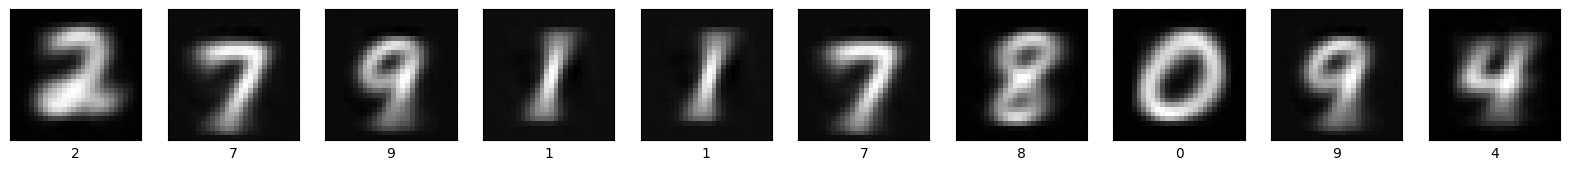

In [5]:
train(
    seed=SEED,
    input_dim=INPUT_DIM,
    width=WIDTH,
    depth=DEPTH,
    output_dim=OUTPUT_DIM,
    act_fn=ACT_FN,
    batch_size=BATCH_SIZE,
    error_lr=ERROR_LR,
    param_lr=PARAM_LR,
    test_every=TEST_EVERY,
    n_train_iters=N_TRAIN_ITERS
)

As with bPC and bePC, downweighting the forward energy (equivalently upweighting the backward / classification energy) biases the joint objective toward classification. We reproduce this knob below with $\alpha_f = 10^{-3}$.

Iter 50, gen loss=248.031738, amort loss=0.288703, avg amort test accuracy=76.802887
Iter 100, gen loss=259.998077, amort loss=0.273983, avg amort test accuracy=80.919472
Iter 150, gen loss=228.225525, amort loss=0.221479, avg amort test accuracy=80.168266
Iter 200, gen loss=238.189789, amort loss=0.256969, avg amort test accuracy=82.351761
Iter 250, gen loss=237.400360, amort loss=0.215310, avg amort test accuracy=80.729164
Iter 300, gen loss=232.261551, amort loss=0.223990, avg amort test accuracy=81.540466


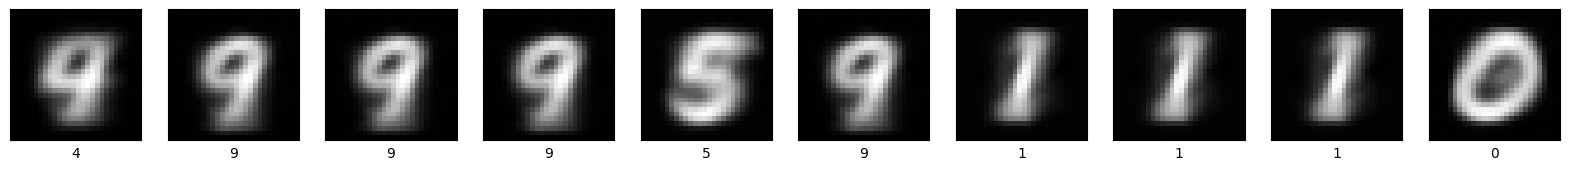

In [6]:
train(
    seed=SEED,
    input_dim=INPUT_DIM,
    width=WIDTH,
    depth=DEPTH,
    output_dim=OUTPUT_DIM,
    act_fn=ACT_FN,
    batch_size=BATCH_SIZE,
    error_lr=ERROR_LR,
    param_lr=PARAM_LR,
    test_every=TEST_EVERY,
    n_train_iters=N_TRAIN_ITERS,
    forward_energy_weight=1e-3
)

## Notes and related examples

- For the non-incremental bidirectional ePC variant, see [`bepc.ipynb`](./bepc.ipynb). For the non-bidirectional incremental ePC variant, see [`iepc.ipynb`](./iepc.ipynb).
- As in bePC, biePC reuses [`jpc.init_epc_errors`](https://thebuckleylab.github.io/jpc/api/Initialisation/) for error initialisation. The top-down network uses these errors exactly as in [`epc.ipynb`](./epc.ipynb), while the bottom-up network is trained on the same error-perturbed activities that drive the bPC backward energy in [`bidirectional_pc.ipynb`](./bidirectional_pc.ipynb).